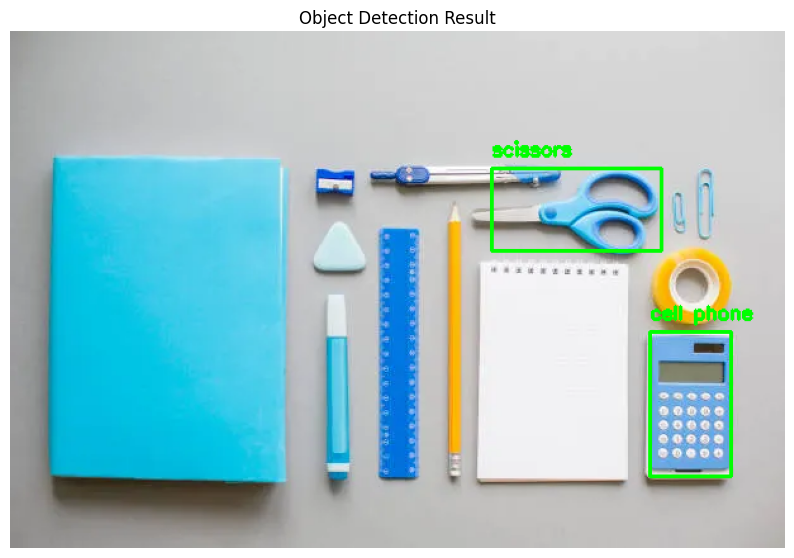

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load class labels
with open("coco.names","r") as f:
    classes = [line.strip() for line in f.readlines()]

# Load YOLO model
net = cv2.dnn.readNet("yolov3.weights","yolov3.cfg")

# Load image
image = cv2.imread("image2.jpeg")
height, width, channels = image.shape

# Create blob
blob = cv2.dnn.blobFromImage(image,1/255,(416,416),(0,0,0),swapRB=True,crop=False)
net.setInput(blob)

# Get output layers
layer_names = net.getLayerNames()
output_layers = [layer_names[i-1] for i in net.getUnconnectedOutLayers()]

# Run detection
outs = net.forward(output_layers)

# Draw bounding boxes
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        if confidence > 0.5:
            center_x = int(detection[0]*width)
            center_y = int(detection[1]*height)

            w = int(detection[2]*width)
            h = int(detection[3]*height)

            x = int(center_x - w/2)
            y = int(center_y - h/2)

            label = classes[class_id]

            cv2.rectangle(image,(x,y),(x+w,y+h),(0,255,0),2)
            cv2.putText(image,label,(x,y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

# Display result in Jupyter
plt.figure(figsize=(10,7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Object Detection Result")
plt.show()